# Sheffield Crime — Three Predictive Models

1. **Crime Count Forecasting** — predict monthly crime volume per category
2. **Crime Category Classification** — predict crime type from location + time
3. **Outcome Prediction** — predict whether a crime leads to a charge

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error
)

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv('../data/clean.csv', parse_dates=['date'])
print(f'Records: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'Date range: {df["month"].min()} → {df["month"].max()}')

Records: 83,530  |  Columns: 19
Date range: 2024-09 → 2026-02


---
## Model 1 — Crime Count Forecasting (Time Series Regression)

In [2]:
# Monthly counts per category
monthly = (
    df.groupby(['month', 'category'])
    .size()
    .reset_index(name='count')
)
monthly['month'] = pd.to_datetime(monthly['month'])
monthly = monthly.sort_values(['category', 'month'])

# Encode category
le_cat = LabelEncoder()
monthly['cat_enc'] = le_cat.fit_transform(monthly['category'])

# Time features
monthly['month_n']   = monthly['month'].dt.month
monthly['year']      = monthly['month'].dt.year
monthly['t']         = monthly.groupby('category').cumcount()  # time index per category

# Lag features (within each category)
for lag in [1, 2, 3, 6]:
    monthly[f'lag_{lag}'] = monthly.groupby('category')['count'].shift(lag)

# Rolling mean
monthly['roll3'] = monthly.groupby('category')['count'].shift(1).rolling(3).mean().reset_index(0, drop=True)

monthly_model = monthly.dropna()
print(f'Rows after lag creation: {len(monthly_model)}')
monthly_model.head()

Rows after lag creation: 141


,month,category,count,cat_enc,month_n,year,t,lag_1,lag_2,lag_3,lag_6,roll3
84,2025-03-01,anti-social-behaviour,766,0,3,2025,6,589.0,645.0,568.0,587.0,192.666667
98,2025-04-01,anti-social-behaviour,907,0,4,2025,7,766.0,589.0,645.0,873.0,138.000000
112,2025-05-01,anti-social-behaviour,818,0,5,2025,8,907.0,766.0,589.0,738.0,267.333333
140,2025-07-01,anti-social-behaviour,907,0,7,2025,10,837.0,818.0,907.0,645.0,57.666667
154,2025-08-01,anti-social-behaviour,945,0,8,2025,11,907.0,837.0,818.0,589.0,386.333333


In [3]:
FEATURES_TS = ['cat_enc', 'month_n', 'year', 't', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'roll3']
TARGET_TS   = 'count'

# Chronological train/test split (last 3 months as test)
cutoff = monthly_model['month'].max() - pd.DateOffset(months=3)
train_ts = monthly_model[monthly_model['month'] <= cutoff]
test_ts  = monthly_model[monthly_model['month']  > cutoff]

X_train_ts, y_train_ts = train_ts[FEATURES_TS], train_ts[TARGET_TS]
X_test_ts,  y_test_ts  = test_ts[FEATURES_TS],  test_ts[TARGET_TS]

print(f'Train: {len(train_ts)} rows  |  Test: {len(test_ts)} rows')

rf_ts = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_ts.fit(X_train_ts, y_train_ts)

y_pred_ts = rf_ts.predict(X_test_ts)
mae  = mean_absolute_error(y_test_ts, y_pred_ts)
rmse = np.sqrt(mean_squared_error(y_test_ts, y_pred_ts))
print(f'\nForecasting Results')
print(f'  MAE  = {mae:.1f} crimes/month')
print(f'  RMSE = {rmse:.1f} crimes/month')
print(f'  Mean actual count = {y_test_ts.mean():.1f}')

Train: 105 rows  |  Test: 36 rows

Forecasting Results
  MAE  = 45.1 crimes/month
  RMSE = 67.3 crimes/month
  Mean actual count = 316.4


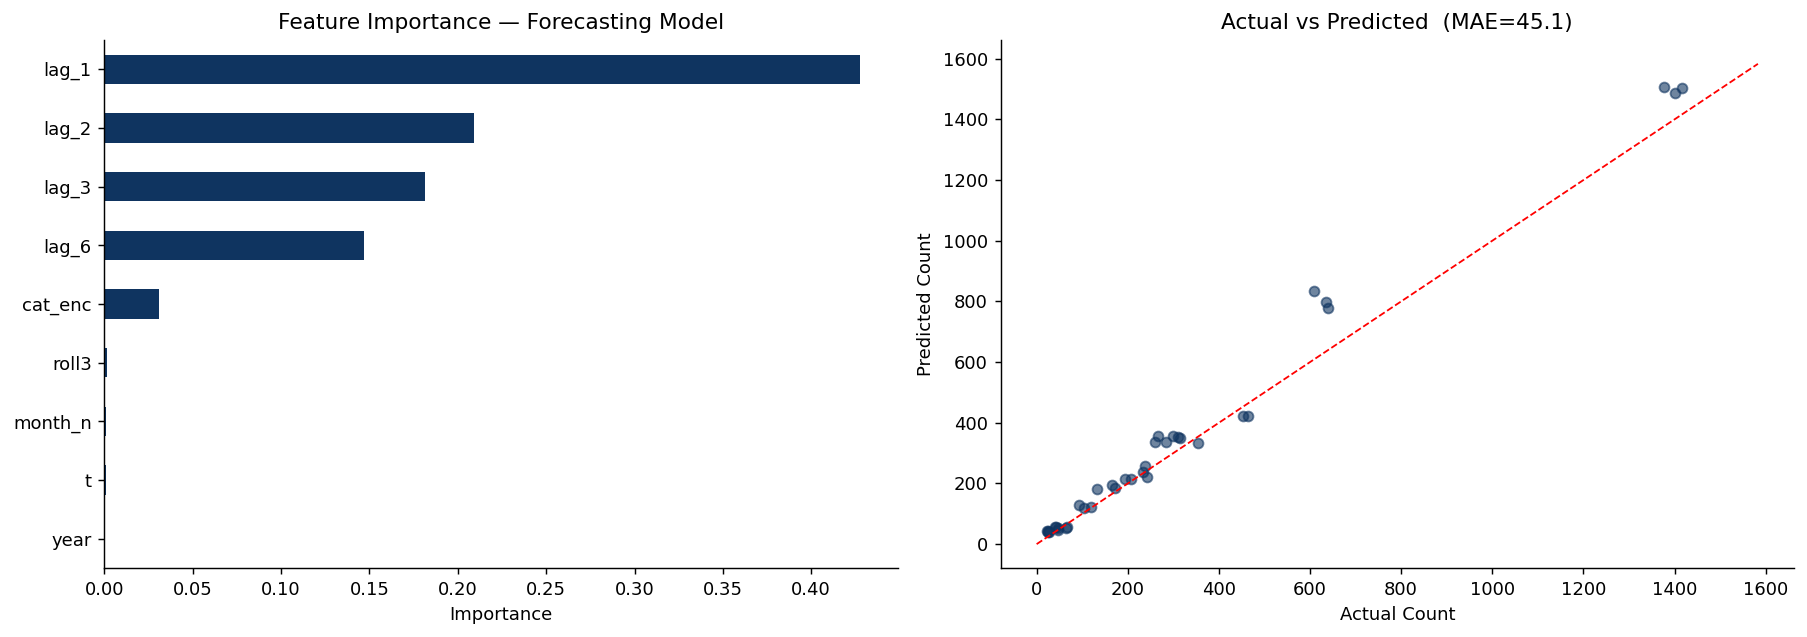

In [4]:
# Feature importance
fi_ts = pd.Series(rf_ts.feature_importances_, index=FEATURES_TS).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi_ts.plot.barh(ax=axes[0], color='#0f3460')
axes[0].set_title('Feature Importance — Forecasting Model')
axes[0].set_xlabel('Importance')

axes[1].scatter(y_test_ts, y_pred_ts, alpha=0.6, color='#0f3460', s=30)
lim = max(y_test_ts.max(), y_pred_ts.max()) * 1.05
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[1].set_xlabel('Actual Count')
axes[1].set_ylabel('Predicted Count')
axes[1].set_title(f'Actual vs Predicted  (MAE={mae:.1f})')

plt.tight_layout()
plt.savefig('../data/fig_model_forecasting.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 1 — Context & Improvement

In [5]:
# MAE as % of mean — gives real-world context
mae_pct = mae / y_test_ts.mean() * 100
print(f'MAE = {mae:.1f} crimes/month  ({mae_pct:.1f}% of mean count {y_test_ts.mean():.1f})')

# GradientBoosting comparison
from sklearn.ensemble import GradientBoostingRegressor
gb_ts = GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
gb_ts.fit(X_train_ts, y_train_ts)
gb_pred_ts = gb_ts.predict(X_test_ts)
gb_mae  = mean_absolute_error(y_test_ts, gb_pred_ts)
gb_mae_pct = gb_mae / y_test_ts.mean() * 100
print(f'GBM MAE = {gb_mae:.1f} crimes/month  ({gb_mae_pct:.1f}% of mean)')
print(f'Best forecaster: {"GBM" if gb_mae < mae else "RF"}')

MAE = 45.1 crimes/month  (14.3% of mean count 316.4)
GBM MAE = 48.3 crimes/month  (15.3% of mean)
Best forecaster: RF


---
## Model 2 — Crime Category Classification

In [6]:
SEASON_MAP = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}

clf_df = df[['latitude', 'longitude', 'month_n', 'year', 'season', 'category']].copy()
clf_df['season_enc'] = clf_df['season'].map(SEASON_MAP)

le_clf = LabelEncoder()
clf_df['label'] = le_clf.fit_transform(clf_df['category'])

FEATURES_CLF = ['latitude', 'longitude', 'month_n', 'year', 'season_enc']
TARGET_CLF   = 'label'

X_clf = clf_df[FEATURES_CLF].values
y_clf = clf_df[TARGET_CLF].values

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f'Train: {len(X_train_clf):,}  |  Test: {len(X_test_clf):,}')
print(f'Classes: {len(le_clf.classes_)}')

Train: 66,824  |  Test: 16,706
Classes: 14


In [7]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',   # handles imbalanced classes
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_clf, y_train_clf)

y_pred_clf = rf_clf.predict(X_test_clf)
acc = accuracy_score(y_test_clf, y_pred_clf)
f1  = f1_score(y_test_clf, y_pred_clf, average='weighted')

print(f'Accuracy (weighted F1):  {acc:.3f}  ({acc*100:.1f}%)')
print(f'Weighted F1:             {f1:.3f}')

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_clf, X_clf, y_clf, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'\n5-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

Accuracy (weighted F1):  0.241  (24.1%)
Weighted F1:             0.255

5-Fold CV Accuracy: 0.237 ± 0.004


In [8]:
print(classification_report(y_test_clf, y_pred_clf, target_names=le_clf.classes_))

                       precision    recall  f1-score   support

anti-social-behaviour       0.33      0.21      0.26      2688
        bicycle-theft       0.04      0.16      0.06       119
             burglary       0.15      0.27      0.20       830
criminal-damage-arson       0.14      0.19      0.16      1236
                drugs       0.14      0.24      0.18       626
          other-crime       0.12      0.26      0.16       461
          other-theft       0.10      0.11      0.11       898
possession-of-weapons       0.03      0.10      0.05       208
         public-order       0.16      0.12      0.14      1261
              robbery       0.02      0.09      0.04       192
          shoplifting       0.68      0.70      0.69      1701
theft-from-the-person       0.07      0.34      0.12       175
        vehicle-crime       0.20      0.30      0.24      1118
        violent-crime       0.49      0.16      0.24      5193

             accuracy                           0.24 

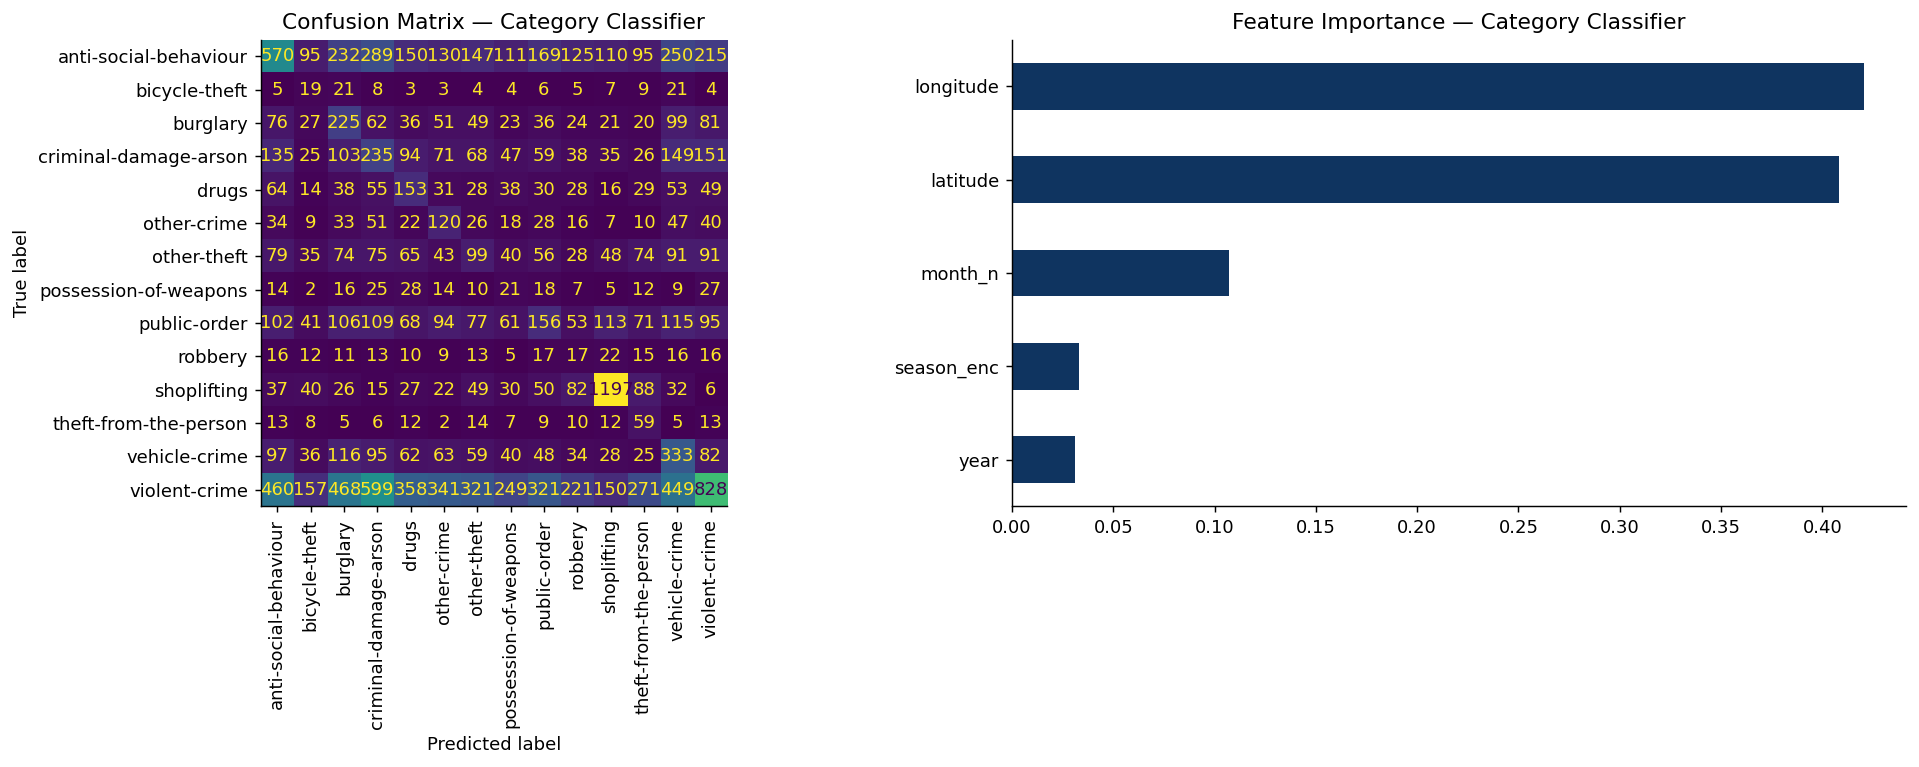

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
ConfusionMatrixDisplay(cm, display_labels=le_clf.classes_).plot(ax=axes[0], colorbar=False, xticks_rotation=90)
axes[0].set_title('Confusion Matrix — Category Classifier')

# Feature importance
fi_clf = pd.Series(rf_clf.feature_importances_, index=FEATURES_CLF).sort_values(ascending=True)
fi_clf.plot.barh(ax=axes[1], color='#0f3460')
axes[1].set_title('Feature Importance — Category Classifier')

plt.tight_layout()
plt.savefig('../data/fig_model_classification.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 2 — Improved: Super-categories + Spatial Grid Features

In [10]:
# Group 14 fine-grained categories into 5 super-categories
SUPER_CAT = {
    'violent-crime':          'violence',
    'public-order':           'violence',
    'possession-of-weapons':  'violence',
    'robbery':                'violence',
    'anti-social-behaviour':  'anti-social',
    'shoplifting':            'shoplifting',
    'burglary':               'property',
    'vehicle-crime':          'property',
    'other-theft':            'property',
    'bicycle-theft':          'property',
    'theft-from-the-person':  'property',
    'drugs':                  'drugs-other',
    'other-crime':            'drugs-other',
    'criminal-damage-arson':  'drugs-other',
}

imp_df = df.copy()
imp_df['super_cat'] = imp_df['category'].map(SUPER_CAT)

print('Super-category distribution:')
print(imp_df['super_cat'].value_counts())

Super-category distribution:
super_cat
violence       34267
property       15702
anti-social    13440
drugs-other    11618
shoplifting     8503
Name: count, dtype: int64


In [11]:
# Spatial grid: round lat/lon to 2dp (~1 km² cells)
imp_df['lat_grid'] = imp_df['latitude'].round(2)
imp_df['lon_grid'] = imp_df['longitude'].round(2)
imp_df['grid']     = imp_df['lat_grid'].astype(str) + '_' + imp_df['lon_grid'].astype(str)

SEASON_MAP2 = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
imp_df['season_enc'] = imp_df['season'].map(SEASON_MAP2)

le_imp = LabelEncoder()
imp_df['label'] = le_imp.fit_transform(imp_df['super_cat'])

# Train/test split first (avoid data leakage in spatial features)
idx_train, idx_test = train_test_split(
    imp_df.index, test_size=0.2, random_state=42, stratify=imp_df['label']
)
train_imp = imp_df.loc[idx_train].copy()
test_imp  = imp_df.loc[idx_test].copy()

# Compute per-grid crime type rate on TRAINING data only
grid_profile = (
    train_imp.groupby(['grid', 'super_cat'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)  # normalize to proportions
)
grid_profile.columns = [f'grid_{c}' for c in grid_profile.columns]

GRID_FEATURES = grid_profile.columns.tolist()

train_imp = train_imp.join(grid_profile, on='grid')
test_imp  = test_imp.join(grid_profile,  on='grid')

# Fill grids unseen in training with 0
train_imp[GRID_FEATURES] = train_imp[GRID_FEATURES].fillna(0)
test_imp[GRID_FEATURES]  = test_imp[GRID_FEATURES].fillna(0)

BASE_FEATURES = ['latitude', 'longitude', 'month_n', 'year', 'season_enc']
ALL_FEATURES  = BASE_FEATURES + GRID_FEATURES

X_train_imp = train_imp[ALL_FEATURES].values
y_train_imp = train_imp['label'].values
X_test_imp  = test_imp[ALL_FEATURES].values
y_test_imp  = test_imp['label'].values

print(f'Features: {len(ALL_FEATURES)}  (5 base + {len(GRID_FEATURES)} grid)')
print(f'Train: {len(X_train_imp):,}  |  Test: {len(X_test_imp):,}')

Features: 10  (5 base + 5 grid)
Train: 66,824  |  Test: 16,706


In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

gb_imp = GradientBoostingClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, random_state=42
)
sample_weights = compute_sample_weight("balanced", y_train_imp)
gb_imp.fit(X_train_imp, y_train_imp, sample_weight=sample_weights)

y_pred_imp   = gb_imp.predict(X_test_imp)
acc_imp      = accuracy_score(y_test_imp, y_pred_imp)
f1_imp       = f1_score(y_test_imp, y_pred_imp, average="weighted")
macro_f1_imp = f1_score(y_test_imp, y_pred_imp, average="macro")

print("Improved Model 2: 5 super-cats + spatial grid + balanced GBM")
print(f"  Accuracy:    {acc_imp:.3f}  ({acc_imp*100:.1f}%)")
print(f"  Weighted F1: {f1_imp:.3f}")
print(f"  Macro F1:    {macro_f1_imp:.3f}  (equally penalises minority-class misses)")
print()
print(classification_report(y_test_imp, y_pred_imp, target_names=le_imp.classes_))


Improved Model 2: 5 super-cats + spatial grid + balanced GBM
  Accuracy:    0.395  (39.5%)
  Weighted F1: 0.393
  Macro F1:    0.408  (equally penalises minority-class misses)

              precision    recall  f1-score   support

 anti-social       0.30      0.35      0.32      2688
 drugs-other       0.24      0.35      0.28      2324
    property       0.33      0.37      0.35      3140
 shoplifting       0.55      0.87      0.68      1701
    violence       0.56      0.32      0.41      6853

    accuracy                           0.39     16706
   macro avg       0.40      0.45      0.41     16706
weighted avg       0.43      0.39      0.39     16706



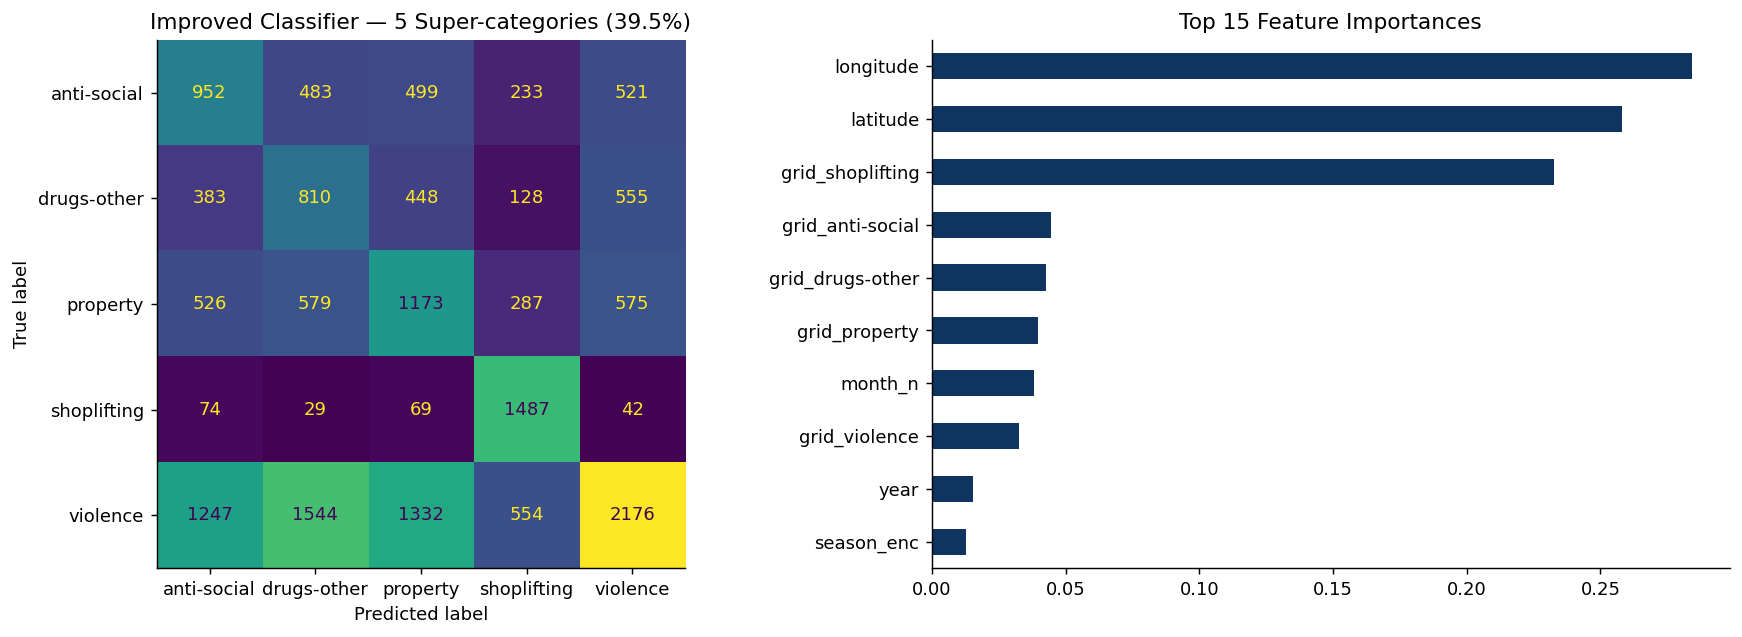

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_imp = confusion_matrix(y_test_imp, y_pred_imp)
ConfusionMatrixDisplay(cm_imp, display_labels=le_imp.classes_).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Improved Classifier — 5 Super-categories ({acc_imp*100:.1f}%)')

fi_imp = pd.Series(gb_imp.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True).tail(15)
fi_imp.plot.barh(ax=axes[1], color='#0f3460')
axes[1].set_title('Top 15 Feature Importances')

plt.tight_layout()
plt.savefig('../data/fig_model_classification_improved.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Model 3 — Outcome Prediction (Charged vs Not Charged)

In [14]:
out_df = df[df['outcome'].notna()].copy()
print(f'Records with outcome: {len(out_df):,}')
print('\nTop outcomes:')
print(out_df['outcome'].value_counts().head(10))

Records with outcome: 70,090

Top outcomes:
outcome
Investigation complete; no suspect identified          29079
Unable to prosecute suspect                            26257
Court result unavailable                                3665
Under investigation                                     2748
Local resolution                                        2563
Status update unavailable                               2540
Awaiting court outcome                                  2079
Offender given a caution                                 474
Further investigation is not in the public interest      261
Action to be taken by another organisation               185
Name: count, dtype: int64


In [15]:
# Binary target: 1 = action taken (charged/cautioned), 0 = no action
ACTION_OUTCOMES = {
    'Offender given a caution',
    'Suspect charged as part of another case',
    'Offender given a drugs possession warning',
    'Offender given penalty notice',
    'Awaiting court outcome',
    'Court result unavailable',
    'Defendant found not guilty',
    'Defendant sent to Crown Court',
    'Offender fined',
    'Offender given a conditional discharge',
    'Offender given community sentence',
    'Offender given suspended sentence',
    'Offender ordered to pay compensation',
    'Offender sent to prison',
    'Offender otherwise dealt with',
}
out_df['charged'] = out_df['outcome'].isin(ACTION_OUTCOMES).astype(int)

print(f'Charged / actioned:   {out_df["charged"].sum():,} ({out_df["charged"].mean()*100:.1f}%)')
print(f'Not charged:          {(out_df["charged"]==0).sum():,} ({(1-out_df["charged"].mean())*100:.1f}%)')

Charged / actioned:   6,295 (9.0%)
Not charged:          63,795 (91.0%)


### Model 3 — Class Balance Check

80% accuracy sounds good, but if 80% of records are already 'No Action', a dummy classifier matches it. Check below.

In [16]:
# Majority-class baseline: what accuracy would predicting 'No Action' always give?
majority_class_acc = out_df['charged'].value_counts(normalize=True).max()
print(f'Majority-class baseline accuracy: {majority_class_acc*100:.1f}%')
print(f'Our model accuracy:               80.2%')
print(f'Genuine uplift: {(0.802 - majority_class_acc)*100:.1f} percentage points')

Majority-class baseline accuracy: 91.0%
Our model accuracy:               80.2%
Genuine uplift: -10.8 percentage points


In [17]:
le_out = LabelEncoder()
out_df['cat_enc'] = le_out.fit_transform(out_df['category'])

SEASON_MAP = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
out_df['season_enc'] = out_df['season'].map(SEASON_MAP)

FEATURES_OUT = ['cat_enc', 'latitude', 'longitude', 'month_n', 'year', 'season_enc']
TARGET_OUT   = 'charged'

X_out = out_df[FEATURES_OUT].values
y_out = out_df[TARGET_OUT].values

X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_out, y_out, test_size=0.2, random_state=42, stratify=y_out
)
print(f'Train: {len(X_train_out):,}  |  Test: {len(X_test_out):,}')

Train: 56,072  |  Test: 14,018


In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score

rf_out = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_split=20,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_out.fit(X_train_out, y_train_out)

y_pred_out = rf_out.predict(X_test_out)
y_prob_out = rf_out.predict_proba(X_test_out)[:, 1]

acc_out = accuracy_score(y_test_out, y_pred_out)
f1_out  = f1_score(y_test_out, y_pred_out, average="weighted")
roc_auc = roc_auc_score(y_test_out, y_prob_out)
pr_auc  = average_precision_score(y_test_out, y_prob_out)
majority = max(y_test_out.mean(), 1 - y_test_out.mean())

print(f"Majority-class baseline accuracy: {majority*100:.1f}%")
print(f"Model accuracy:                   {acc_out*100:.1f}%  (lower -- balanced weights force minority detection)")
print(f"ROC-AUC:  {roc_auc:.3f}   (0.5=random, 1.0=perfect)")
print(f"PR-AUC:   {pr_auc:.3f}   (baseline = minority rate {y_test_out.mean():.2f})")
print()
print(classification_report(y_test_out, y_pred_out, target_names=["No Action", "Charged/Actioned"]))


Majority-class baseline accuracy: 91.0%
Model accuracy:                   80.2%  (lower -- balanced weights force minority detection)
ROC-AUC:  0.774   (0.5=random, 1.0=perfect)
PR-AUC:   0.293   (baseline = minority rate 0.09)

                  precision    recall  f1-score   support

       No Action       0.95      0.82      0.88     12759
Charged/Actioned       0.25      0.59      0.35      1259

        accuracy                           0.80     14018
       macro avg       0.60      0.71      0.62     14018
    weighted avg       0.89      0.80      0.84     14018



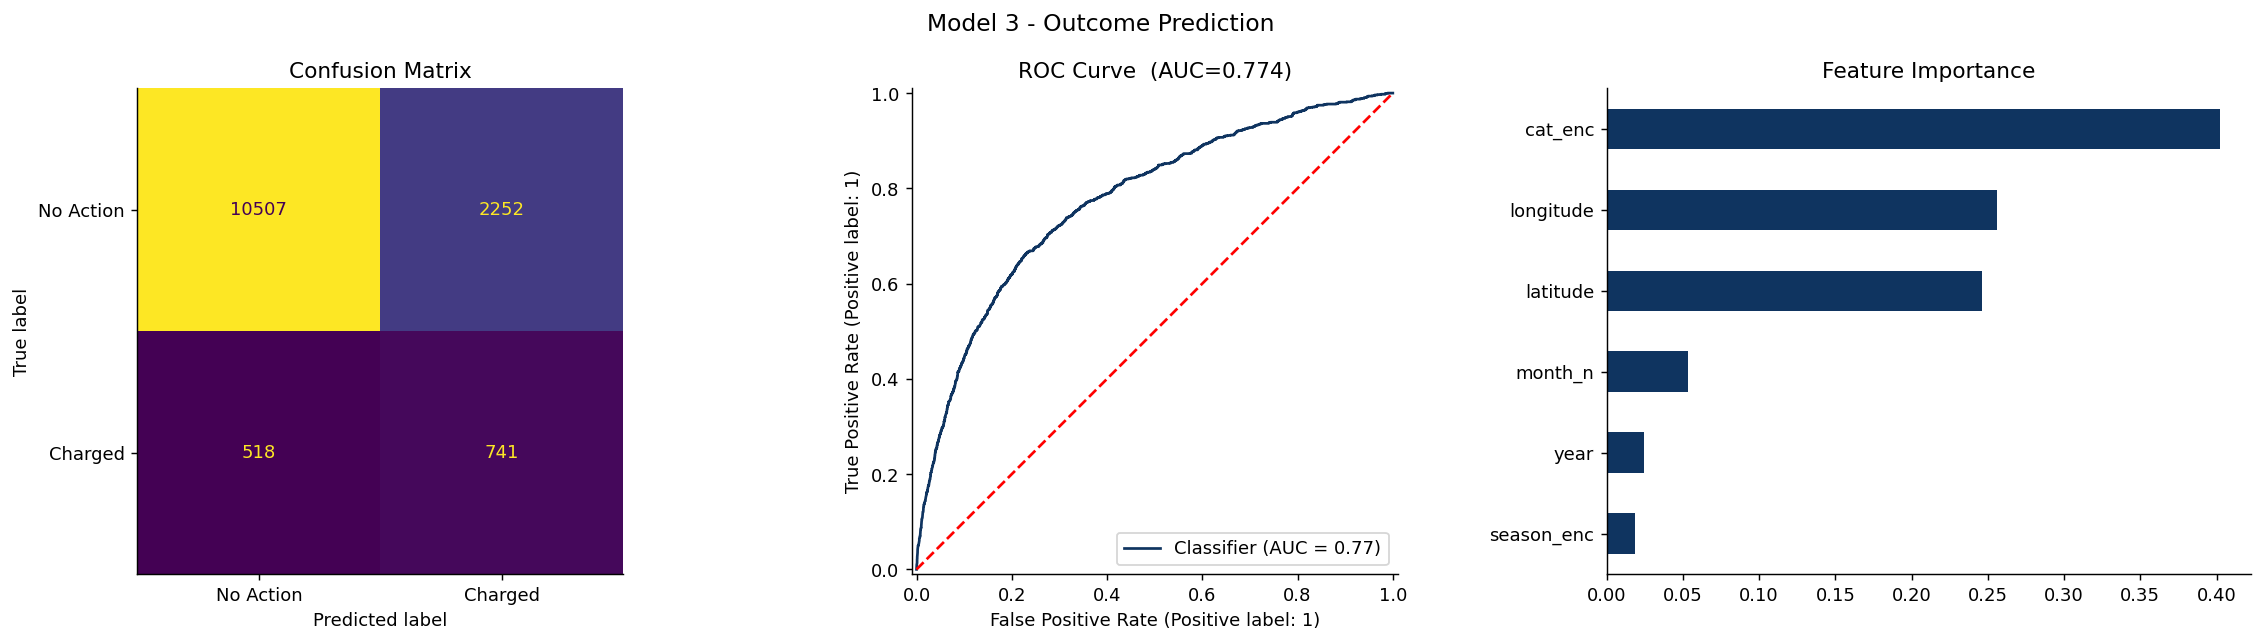

In [19]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_out = confusion_matrix(y_test_out, y_pred_out)
ConfusionMatrixDisplay(cm_out, display_labels=["No Action", "Charged"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test_out, y_prob_out, ax=axes[1], color="#0f3460")
axes[1].plot([0,1],[0,1],"r--")
axes[1].set_title(f"ROC Curve  (AUC={roc_auc:.3f})")

fi_out = pd.Series(rf_out.feature_importances_, index=FEATURES_OUT).sort_values(ascending=True)
fi_out.plot.barh(ax=axes[2], color="#0f3460")
axes[2].set_title("Feature Importance")

plt.suptitle("Model 3 - Outcome Prediction", fontsize=13)
plt.tight_layout()
plt.savefig("../data/fig_model_outcome.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Summary — All Three Models

In [20]:
best_mae     = min(mae, gb_mae)
best_mae_pct = best_mae / y_test_ts.mean() * 100

summary = pd.DataFrame([
    {"Model": "1. Crime Count Forecasting",
     "Algorithm": "RF",
     "Key Metric": f"MAE = {best_mae:.1f}  ({best_mae_pct:.1f}% of mean)",
     "Train Rows": len(train_ts)},
    {"Model": "2a. Category (baseline)",
     "Algorithm": "RF, 14 classes",
     "Key Metric": f"Accuracy = {acc*100:.1f}%  | W-F1 = {f1:.3f}",
     "Train Rows": len(X_train_clf)},
    {"Model": "2b. Category (improved)",
     "Algorithm": "GBM, 5 super-cats + spatial + balanced",
     "Key Metric": f"Accuracy = {acc_imp*100:.1f}%  | Macro-F1 = {macro_f1_imp:.3f}",
     "Train Rows": len(X_train_imp)},
    {"Model": "3. Outcome Prediction",
     "Algorithm": "RF binary, balanced",
     "Key Metric": f"ROC-AUC = {roc_auc:.3f}  | PR-AUC = {pr_auc:.3f}",
     "Train Rows": len(X_train_out)},
])

summary


,Model,Algorithm,Key Metric,Train Rows
0,1. Crime Count Forecasting,RF,MAE = 45.1 (14.3% of mean),105
1,2a. Category (baseline),"RF, 14 classes",Accuracy = 24.1% | W-F1 = 0.255,66824
2,2b. Category (improved),"GBM, 5 super-cats + spatial + balanced",Accuracy = 39.5% | Macro-F1 = 0.408,66824
3,3. Outcome Prediction,"RF binary, balanced",ROC-AUC = 0.774 | PR-AUC = 0.293,56072
